# 4-2. [리뷰 이벤트] 검증코드 (KNN, 그래프)

**노션 "4-2. 리뷰 조건 할인" 섹션의 숫자와 그래프를 원본 데이터에서 다시 계산하는 노트북입니다.**

| 노션 문장 | 검증하는 셀 |
| --- | --- |
| 조건이 비슷한 리뷰 있는 숙소보다 비싼 리뷰 없는 숙소: 단·중기 163,939곳 중 100,850곳(61.5%) | 3장 |
| 1.5배 이상 비싼 숙소 30.1% (리뷰 있는 곳의 약 2배) | 3장, 4장 |
| 리뷰 없는 숙소의 93.7%는 조건이 완전히 같은 리뷰 있는 숙소가 있음 | 5장 |
| 그래프 "안 팔린 숙소가 팔린 숙소에 비해 비싸다 (KNN)" | 6장 |

**용어**
- **리뷰O (활성)**: 최근 12개월 리뷰가 1건 이상 (`number_of_reviews_ltm` > 0)
- **리뷰X (비활성)**: 최근 12개월 리뷰 0건
- **단기**: `minimum_nights` 1–3박 / **중기**: 4–29박 (30박 이상은 제외)
- **기준가**: 조건이 가장 비슷한 리뷰O 숙소 15곳의 1박 가격 중앙값 (KNN, K=15)
- **상대 가격**: 내 1박 가격 ÷ 기준가. 1보다 크면 "비슷한 리뷰O 숙소보다 비쌈"

전체 실행에 약 5–10분 걸립니다(데이터 읽기 + KNN).

## 0. 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

DATA = 'InsightStay_data_cleaned.csv'   # 이 노트북과 같은 폴더(insight_con)에 있는 파일
K = 15                                   # 비교할 이웃 수
MIN_PRICED = 10                          # 이웃 15곳 중 가격 있는 곳이 이보다 적으면 비교에서 제외
ID_CUT = 1.43e18                         # 등록 1년 미만으로 추정하는 숙소 ID 기준

pd.set_option('display.width', 200)
plt.rcParams.update({'font.family': 'Malgun Gothic',   # 맥이면 'AppleGothic'
                     'axes.unicode_minus': False})

## 1. 데이터 불러오기와 정의

- 분석 대상은 `source = 0` (도시 검색에서 수집된 숙소)만 씁니다.
- 가격은 `price`(할인 후 1박 가격)를 쓰고, 이상값(10유로 미만, 1인당 1,000유로 초과)은 가격 없음으로 처리합니다.
- `bedrooms`가 비어 있으면 인원 ÷ 2, `bathrooms`가 비어 있으면 1로 채웁니다.
- 숙소 유형(`property_type`)은 **아파트형 / 단독·빌라 / 방** 3가지로 묶습니다.
- **신규 숙소**(리뷰가 한 번도 없고 등록 1년 미만으로 추정)는 신규인 리뷰O 숙소와만 비교합니다. 리뷰가 쌓인 오래된 숙소와 비교하면 불공평하기 때문입니다.

In [2]:
cols = ['source', 'id', 'region', 'room_type', 'property_type', 'accommodates', 'bedrooms', 'bathrooms',
        'price', 'flag_price_under_10', 'flag_price_per_person_over_1000', 'minimum_nights',
        'number_of_reviews', 'number_of_reviews_ltm', 'hosts_time_as_host_years', 'hosts_time_as_host_months']
df = pd.read_csv(DATA, usecols=cols, dtype={'id': 'string'})
df = df[df.source == 0].reset_index(drop=True)

# 리뷰O / 리뷰X
df['review_o'] = df.number_of_reviews_ltm > 0

# 숙박 구간
df['stay'] = np.select([df.minimum_nights <= 3, df.minimum_nights <= 29], ['단기', '중기'], '장기')

# 가격 (이상값 제외)
bad = df.flag_price_under_10.fillna(False).astype(bool) | df.flag_price_per_person_over_1000.fillna(False).astype(bool)
df['p'] = df.price.where(~bad)

# 숙소 유형 3가지
pt = df.property_type.fillna('')
df['ptype'] = np.select([pt.str.contains('villa|home|house|cottage|chalet|bungalow', case=False),
                         pt.str.contains('room', case=False)], ['단독·빌라', '방'], '아파트형')

# 크기 (빈 값 채우기)
df['bed'] = df.bedrooms.fillna(df.accommodates / 2).clip(0, 10)
df['bath'] = df.bathrooms.fillna(1).clip(0, 6)

# 신규 (등록 1년 미만 추정)
host_m = df.hosts_time_as_host_years * 12 + df.hosts_time_as_host_months
df['young'] = (df.id.astype('float64') >= ID_CUT) | (host_m < 12)
df['new'] = (df.number_of_reviews == 0) & df.young      # 리뷰X 중 신규 숙소

print(f'source=0 숙소 {len(df):,}곳')
print(pd.crosstab(df.stay, df.review_o.map({True: '리뷰O', False: '리뷰X'}), margins=True, margins_name='합계'))

source=0 숙소 678,130곳
review_o     리뷰O     리뷰X      합계
stay                            
단기        418900  144645  563545
장기          9562   28361   37923
중기         43293   33369   76662
합계        471755  206375  678130


## 2. KNN: 리뷰X 숙소마다 "비슷한 리뷰O 숙소 15곳" 찾기

**바꿀 수 없는 조건만** 씁니다.
- **같은 값끼리 묶기**: `region`, `room_type`, `property_type`(3가지), 숙박 구간(단기/중기)
- **묶음 안에서 거리 계산**: `accommodates`, `bedrooms`, `bathrooms` (단위를 맞추려고 표준화)
- 묶음 안에 리뷰O 숙소가 15곳보다 적으면, `property_type` 조건을 빼고 다시 찾습니다. (리뷰O 숙소는 자기 자신을 빼야 하므로 16곳 이상 필요)

리뷰O 숙소도 같은 방식으로 **자기 자신을 뺀** 비슷한 리뷰O 숙소 15곳과 비교합니다(4장의 비교 기준선).

In [3]:
FEAT = ['accommodates', 'bed', 'bath']
X = StandardScaler().fit_transform(df[FEAT].clip(upper=df[FEAT].quantile(.995), axis=1))
P = df.p.to_numpy(float)
is_o = df.review_o.to_numpy()
young = df.young.to_numpy()
new = df.new.to_numpy()
# 비교 그룹: 리뷰X는 신규 여부, 리뷰O는 등록 1년 미만 여부로 "신규끼리 / 기존끼리"를 나눈다
q_new = np.where(is_o, young, new)

LEVELS = [['region', 'room_type', 'ptype', 'stay'],   # 기본
          ['region', 'room_type', 'stay']]            # 리뷰O가 15곳보다 적을 때
base = np.full(len(df), np.nan)       # 기준가
n_priced = np.zeros(len(df), int)     # 이웃 15곳 중 가격 있는 곳 수
done = np.zeros(len(df), bool)
target = df.stay.isin(['단기', '중기']).to_numpy()

for keys in LEVELS:
    for _, g in df[target].groupby(keys).groups.items():
        gi = np.asarray(g)
        for is_new in [True, False]:
            pool = gi[is_o[gi] & (young[gi] if is_new else True)]      # 이웃 후보: 리뷰O
            if len(pool) < K:
                continue
            q = gi[~done[gi] & (q_new[gi] == is_new)]                  # 비교할 숙소
            if len(pool) == K:                                         # 리뷰O는 자기 자신을 빼면 14곳뿐이라 제외
                q = q[~is_o[q]]
            if len(q) == 0:
                continue
            nn = NearestNeighbors(n_neighbors=K).fit(X[pool])
            # 리뷰X 숙소: 가장 가까운 리뷰O 15곳
            qx = q[~is_o[q]]
            if len(qx):
                _, idx = nn.kneighbors(X[qx])
                prices = P[pool[idx]]
                base[qx] = np.nanmedian(prices, 1)
                n_priced[qx] = np.isfinite(prices).sum(1)
            # 리뷰O 숙소: 자기 자신을 뺀 가장 가까운 리뷰O 15곳
            qo = q[is_o[q]]
            if len(qo):
                _, idx = nn.kneighbors(X[qo], n_neighbors=K + 1)
                nb = pool[idx]
                is_self = nb == qo[:, None]
                keep = np.where(is_self.any(1)[:, None], ~is_self, np.arange(K + 1) < K)
                prices = np.where(keep, P[nb], np.nan)
                base[qo] = np.nanmedian(prices, 1)
                n_priced[qo] = np.isfinite(prices).sum(1)
            done[q] = True

df['base'] = base
df['n_priced'] = n_priced
df['rel'] = df.p / df.base
print('이웃을 찾은 단·중기 숙소:', f'{int(done[target].sum()):,}곳 / {int(target.sum()):,}곳')

이웃을 찾은 단·중기 숙소: 637,864곳 / 640,207곳


## 3. 결과: 리뷰X 숙소의 몇 %가 비슷한 리뷰O 숙소보다 비싼가

비교 가능한 숙소만 셉니다.
- 이웃 15곳을 찾았고
- 내 가격이 있고
- 이웃 15곳 중 가격 있는 곳이 10곳 이상

In [4]:
comp = df[target & done & df.p.notna() & (df.n_priced >= MIN_PRICED)].copy()
x = comp[~comp.review_o]

n = len(x)
n_exp = int((x.rel > 1).sum())
print(f'비교한 리뷰X 단·중기 숙소: {n:,}곳')
print(f'기준가보다 비쌈: {n_exp:,}곳 ({n_exp / n * 100:.1f}%)')
print()
for s in ['단기', '중기']:
    xs = x[x.stay == s]
    print(f'  {s}: {len(xs):,}곳 중 {int((xs.rel > 1).sum()):,}곳 ({(xs.rel > 1).mean() * 100:.1f}%), '
          f'상대 가격 중앙값 {xs.rel.median():.2f}배')

비교한 리뷰X 단·중기 숙소: 163,939곳
기준가보다 비쌈: 100,850곳 (61.5%)

  단기: 133,473곳 중 83,641곳 (62.7%), 상대 가격 중앙값 1.16배
  중기: 30,466곳 중 17,209곳 (56.5%), 상대 가격 중앙값 1.08배


In [5]:
# 얼마나 비싼가: 구간별 숙소 수와 비율
bins = [0, 1, 1.1, 1.3, 1.5, 2, 3, np.inf]
labels = ['기준가 이하', '1.0–1.1배', '1.1–1.3배', '1.3–1.5배', '1.5–2배', '2–3배', '3배 이상']
t = pd.cut(x.rel, bins, labels=labels).value_counts().reindex(labels).to_frame('숙소 수')
t['리뷰X 전체 중 %'] = (t['숙소 수'] / n * 100).round(1)
exp = t.loc[labels[1:], '숙소 수']
t.loc[labels[1:], '비싼 숙소 중 %'] = (exp / exp.sum() * 100).round(1)
t.loc['합계'] = [n, 100.0, np.nan]
t

,숙소 수,리뷰X 전체 중 %,비싼 숙소 중 %
rel,,,
기준가 이하,63089.0,38.5,NaN
1.0–1.1배,12940.0,7.9,12.8
1.1–1.3배,22326.0,13.6,22.1
1.3–1.5배,16253.0,9.9,16.1
1.5–2배,22645.0,13.8,22.5
2–3배,15537.0,9.5,15.4
3배 이상,11149.0,6.8,11.1
합계,163939.0,100.0,NaN


In [6]:
over15 = int((x.rel > 1.5).sum())   # 구간 표와 같게 1.5배 초과 (정확히 1.5배는 1.3–1.5배 구간)
print(f'1.5배 이상: {over15:,}곳 (비싼 숙소의 {over15 / n_exp * 100:.1f}%, 리뷰X 전체의 {over15 / n * 100:.1f}%)')

1.5배 이상: 49,331곳 (비싼 숙소의 48.9%, 리뷰X 전체의 30.1%)


## 4. 비교 기준선: 리뷰O 숙소도 같은 방식으로 비교하면?

중앙값은 원래 "절반이 위, 절반이 아래"인 값이라, 어떤 숙소든 이웃 중앙값과 비교하면 절반쯤은 "비싸다"로 나옵니다. 그래서 **리뷰O 숙소에도 같은 계산을 해서**(자기 자신은 이웃에서 제외) 리뷰X와 비교합니다.

In [7]:
o = comp[comp.review_o]
def share(d):
    return pd.Series({'숙소 수': len(d),
                      '기준가 이하 %': (d.rel <= 1).mean() * 100,
                      '1.0–1.5배 %': d.rel.between(1, 1.5, inclusive='right').mean() * 100,
                      '1.5배 이상 %': (d.rel > 1.5).mean() * 100,
                      '비쌈(>1) %': (d.rel > 1).mean() * 100})
base_tbl = pd.DataFrame({'리뷰O (비교 기준)': share(o), '리뷰X': share(x)}).T.round(1)
base_tbl

,숙소 수,기준가 이하 %,1.0–1.5배 %,1.5배 이상 %,비쌈(>1) %
리뷰O (비교 기준),448799.0,48.9,34.2,16.8,51.1
리뷰X,163939.0,38.5,31.4,30.1,61.5


In [8]:
r_o, r_x = base_tbl.loc['리뷰O (비교 기준)'], base_tbl.loc['리뷰X']
print(f"비쌈: 리뷰O {r_o['비쌈(>1) %']:.1f}% vs 리뷰X {r_x['비쌈(>1) %']:.1f}% → {r_x['비쌈(>1) %'] - r_o['비쌈(>1) %']:+.1f}%p")
print(f"1.5배 이상: 리뷰O {r_o['1.5배 이상 %']:.1f}% vs 리뷰X {r_x['1.5배 이상 %']:.1f}% → {r_x['1.5배 이상 %'] / r_o['1.5배 이상 %']:.1f}배")

비쌈: 리뷰O 51.1% vs 리뷰X 61.5% → +10.4%p
1.5배 이상: 리뷰O 16.8% vs 리뷰X 30.1% → 1.8배


## 5. 리뷰X 숙소의 몇 %가 "조건이 완전히 같은" 리뷰O 숙소를 갖고 있나

KNN과 별도로, 바꿀 수 없는 조건이 **전부 같은** 리뷰O 숙소(쌍둥이)를 셉니다.
- 같아야 하는 조건: `region`, `room_type`, `property_type`(3가지), 숙박 구간, `accommodates`, `bedrooms`, `bathrooms`
- 신규 숙소는 신규 리뷰O 숙소 중에서 셉니다.
- 분모는 리뷰X 단·중기 숙소 **전체**입니다(가격이 없는 숙소도 포함).

In [9]:
df['bed_i'] = df.bed.round()
E = ['region', 'room_type', 'ptype', 'stay', 'accommodates', 'bed_i', 'bath']
sold = df[df.review_o & target]
cnt_all = sold.groupby(E).size().rename('twin_all')
cnt_young = sold[sold.young].groupby(E).size().rename('twin_young')

xx = df[~df.review_o & target].merge(cnt_all, left_on=E, right_index=True, how='left') \
                              .merge(cnt_young, left_on=E, right_index=True, how='left')
xx['twin'] = np.where(xx.new, xx.twin_young, xx.twin_all)
xx['twin'] = xx.twin.fillna(0)

tw = pd.DataFrame({s: [len(d), int((d.twin >= 1).sum()), (d.twin >= 1).mean() * 100, (d.twin >= 15).mean() * 100]
                   for s, d in [('단기', xx[xx.stay == '단기']), ('중기', xx[xx.stay == '중기']), ('단·중기 합계', xx)]},
                  index=['리뷰X 숙소', '쌍둥이 1곳 이상', '쌍둥이 1곳 이상 %', '쌍둥이 15곳 이상 %']).T
tw.round(1)

,리뷰X 숙소,쌍둥이 1곳 이상,쌍둥이 1곳 이상 %,쌍둥이 15곳 이상 %
단기,144645.0,138082.0,95.5,82.1
중기,33369.0,28645.0,85.8,51.5
단·중기 합계,178014.0,166727.0,93.7,76.4


## 6. 그래프: 안 팔린 숙소가 팔린 숙소에 비해 비싸다 (KNN)

리뷰O(비교 기준)와 리뷰X를 같은 잣대(비슷한 리뷰O 숙소 15곳의 가격 중앙값)로 잰 결과입니다.

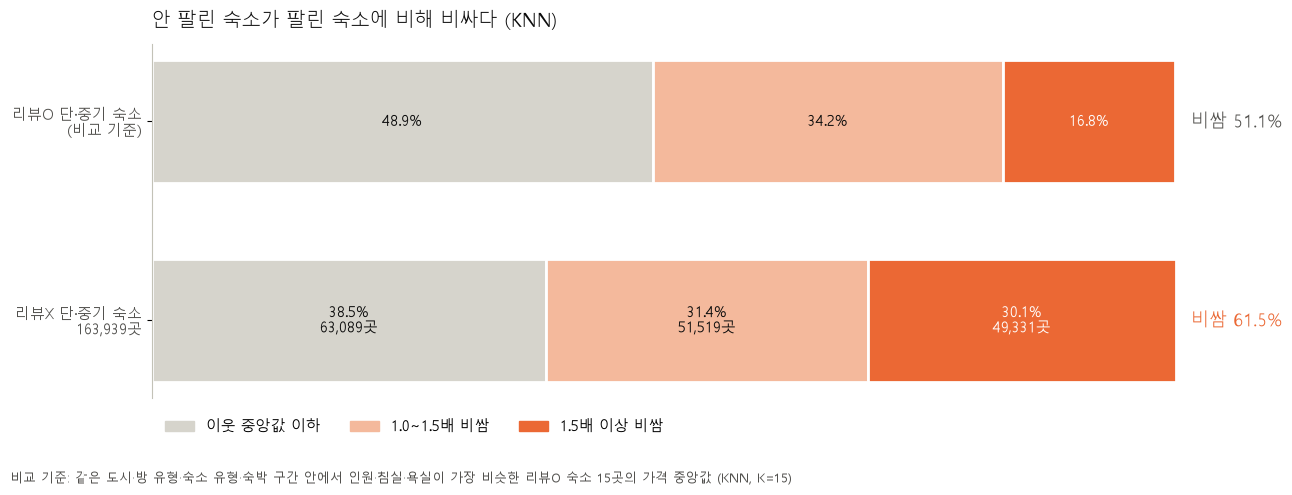

In [10]:
GRAY, LIGHT, ORANGE, INK, INK2 = '#d6d4cc', '#f4b99c', '#eb6834', '#0b0b0b', '#52514e'
seg_cols = ['기준가 이하 %', '1.0–1.5배 %', '1.5배 이상 %']
seg_lab = ['이웃 중앙값 이하', '1.0~1.5배 비쌈', '1.5배 이상 비쌈']
colors = [GRAY, LIGHT, ORANGE]
rows = [('리뷰O 단·중기 숙소\n(비교 기준)', o, base_tbl.loc['리뷰O (비교 기준)']),
        (f'리뷰X 단·중기 숙소\n{len(x):,}곳', x, base_tbl.loc['리뷰X'])]
counts_x = [int((x.rel <= 1).sum()), int(x.rel.between(1, 1.5, inclusive='right').sum()), int((x.rel > 1.5).sum())]

fig, ax = plt.subplots(figsize=(13, 4.6))
for yi, (name, d, r) in enumerate(rows[::-1]):          # 위: 리뷰O, 아래: 리뷰X
    left = 0
    for j, (c, col) in enumerate(zip(seg_cols, colors)):
        w = r[c]
        ax.barh(yi, w, left=left, color=col, height=.62, edgecolor='white', linewidth=2)
        txt = f'{w:.1f}%' if name.startswith('리뷰O') else f'{w:.1f}%\n{counts_x[j]:,}곳'
        ax.text(left + w / 2, yi, txt, ha='center', va='center', fontsize=11,
                color='white' if col == ORANGE else INK)
        left += w
    ax.text(101.5, yi, f"비쌈 {r['비쌈(>1) %']:.1f}%", va='center', fontsize=13,
            color=ORANGE if name.startswith('리뷰X') else INK2)

ax.set_yticks([0, 1]); ax.set_yticklabels([rows[1][0], rows[0][0]], fontsize=11, color=INK2)
ax.set_xlim(0, 100); ax.set_xticks([])
for s in ['top', 'right', 'bottom']: ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#c3c2b7')
ax.set_title('안 팔린 숙소가 팔린 숙소에 비해 비싸다 (KNN)', loc='left', fontsize=14, color=INK, pad=12)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
ax.legend(handles, seg_lab, loc='upper left', bbox_to_anchor=(0, -0.02), ncol=3, frameon=False, fontsize=10.5)
fig.text(0.01, -0.06, '비교 기준: 같은 도시·방 유형·숙소 유형·숙박 구간 안에서 인원·침실·욕실이 가장 비슷한 리뷰O 숙소 15곳의 가격 중앙값 (KNN, K=15)',
         fontsize=9, color=INK2)
fig.tight_layout()
fig.savefig('4-2_리뷰이벤트_가격비교.png', dpi=150, bbox_inches='tight')
plt.show()